transaction_date     object
transaction_month     int64
transaction_day       int64
transaction_hour      int64
dtype: object
Mean absolute errror: 8.40930
Mean squared errror: 189.80520
Root mean squared errror: 13.77698
R2 score: 0.32267


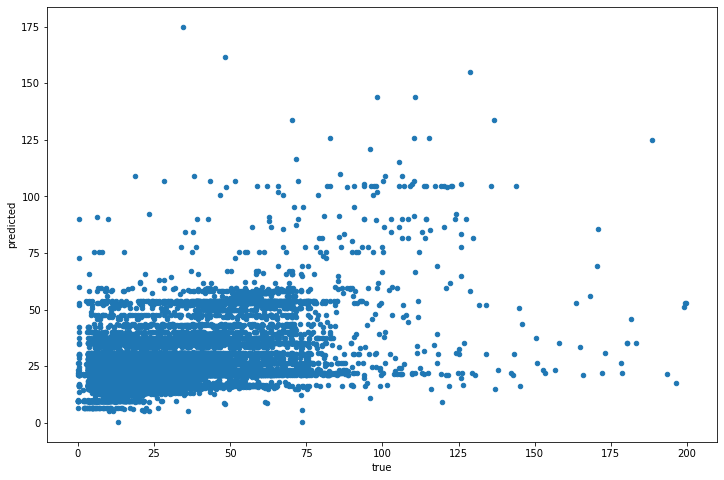

In [27]:
# start coding from here - load grouped data file size 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

taxi_grouped_by_region = pd.read_csv('data/taxi_grouped.csv')
taxi_grouped_by_region = taxi_grouped_by_region.drop(labels='Unnamed: 0', axis=1)

print(taxi_grouped_by_region[['transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']].dtypes)
data_for_benchmark_model = taxi_grouped_by_region.copy()

categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = ['total_amount']

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]
X_bench.dtypes

# one-hot encode
X_bench = pd.get_dummies(X_bench)

# split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# fit a model
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

# model evaluation
model_at_hand = tree
y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

print(f'Mean absolute errror: {mean_absolute_error(y_test_b, y_pred_b):.5f}')
print(f'Mean squared errror: {mean_squared_error(y_test_b, y_pred_b):.5f}')
print(f'Root mean squared errror: {sqrt(mean_squared_error(y_test_b, y_pred_b)):.5f}')
print(f'R2 score: {r2_score(y_test_b, y_pred_b):.5f}')

data = {'true': y_test_b.iloc[:, 0], 'predicted': y_pred_b}
# test: DataFrame - predicted: numpy array

results = pd.DataFrame(data)
results.plot(kind='scatter', x='true', y='predicted', figsize=(12, 8))
plt.show()



# 6 Data engineering

In [28]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


In [29]:
data_with_new_features = taxi_grouped_by_region.copy()

Data related features

In [30]:
data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date'])
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday

print(f'Here the week starts from 0 which is Monday')
print(data_with_new_features['transaction_week_day'].value_counts().index)
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 | x == 6 else False)

Here the week starts from 0 which is Monday
Index([2, 3, 1, 4, 0, 5, 6], dtype='int32', name='transaction_week_day')


In [31]:
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True


Borough information

In [32]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
# zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)

print(f'{zone_lookup.dtypes}')
print(f"PULocationID_type: {data_with_new_features['PULocationID'].dtype}")

LocationID     int64
Borough       object
dtype: object
PULocationID_type: int64


In [33]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features = data_with_new_features.drop(labels='LocationID', axis=1)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [34]:
print(data_with_new_features.isna().sum())
data_with_new_features['Borough'].value_counts()

PULocationID               0
transaction_date           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                  709
dtype: int64


Borough
Manhattan        45309
Brooklyn         23633
Queens           22002
Bronx             9586
Unknown            744
Staten Island      302
EWR                271
Name: count, dtype: int64

Weather related features

In [38]:
import requests
import pandas as pd

params = {
    'latitude': 40.7128,
    'longitude': -74.0060,
    'start_date': '2019-01-01',
    'end_date': '2019-01-31',
    'hourly': 'temperature_2m,relative_humidity_2m,cloudcover,windspeed_10m,precipitation',
    'timezone': 'America/New_York'
}

response = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params)

print(response.json().keys())
print(response.json()['hourly'].keys())

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data['hourly'], columns=['time', 'temperature_2m', 'relative_humidity_2m', 'windspeed_10m', 'cloudcover', 'precipitation'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df_3H = df.resample('3H').agg({
        'temperature_2m': 'mean', 
        'relative_humidity_2m': 'mean', 
        'windspeed_10m': 'mean', 
        'cloudcover': 'mean', 
        'precipitation': 'sum'
    })

    df_3H.to_csv('data/nyc_weather_no_missing values.csv')
    print(f'Weather data file saved correctly - status code: {response.status_code}')

else:
    print(f'Something went wrong - status code: {response.status_code}')

df_3H.head()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'cloudcover', 'windspeed_10m', 'precipitation'])
Weather data file saved correctly - status code: 200


,temperature_2m,relative_humidity_2m,windspeed_10m,cloudcover,precipitation
time,,,,,
2019-01-01 00:00:00,8.700000,97.000000,16.100000,100.000000,7.1
2019-01-01 03:00:00,12.366667,94.333333,26.600000,99.000000,0.4
2019-01-01 06:00:00,13.600000,90.000000,29.633333,86.666667,0.0
2019-01-01 09:00:00,13.933333,74.333333,32.400000,99.000000,0.0
2019-01-01 12:00:00,11.500000,60.333333,33.400000,75.666667,0.0


In [36]:
index = pd.date_range('1/1/2000', periods=9, freq='H')
series = pd.Series(range(9), index=index)
print(series)

series.resample('3H').agg('sum')

2000-01-01 00:00:00    0
2000-01-01 01:00:00    1
2000-01-01 02:00:00    2
2000-01-01 03:00:00    3
2000-01-01 04:00:00    4
2000-01-01 05:00:00    5
2000-01-01 06:00:00    6
2000-01-01 07:00:00    7
2000-01-01 08:00:00    8
Freq: H, dtype: int64


2000-01-01 00:00:00     3
2000-01-01 03:00:00    12
2000-01-01 06:00:00    21
Freq: 3H, dtype: int64

In [42]:
# The source file has been modified to present how to deal with missing values, strings
nyc_weather = pd.read_csv('data/nyc_weather_missing_values.csv')
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,2019-01-01 00:00:00,8.700000,97.000000,16.100000,100%.,7.1
1,2019-01-01 03:00:00,12.366667,94.333333,26.600000,100%.,0.4
2,2019-01-01 06:00:00,13.600000,90.000000,29.633333,70 – 80%.,Trace of precipitation
3,2019-01-01 09:00:00,13.933333,74.333333,32.400000,100%.,Trace of precipitation
4,2019-01-01 12:00:00,11.500000,60.333333,33.400000,70 – 80%.,Trace of precipitation
